In [ ]:
from sklearn.datasets import fetch_openml

# Lee el dataset desde OpenMl utilizando la funcionalidad de SKLearn
har_dataset = fetch_openml(data_id=43347)
print(har_dataset.data)
print(har_dataset.target)

       species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0       Adelie  Torgersen            39.1           18.7              181.0   
1       Adelie  Torgersen            39.5           17.4              186.0   
2       Adelie  Torgersen            40.3           18.0              195.0   
3       Adelie  Torgersen             NaN            NaN                NaN   
4       Adelie  Torgersen            36.7           19.3              193.0   
..         ...        ...             ...            ...                ...   
339  Chinstrap      Dream            55.8           19.8              207.0   
340  Chinstrap      Dream            43.5           18.1              202.0   
341  Chinstrap      Dream            49.6           18.2              193.0   
342  Chinstrap      Dream            50.8           19.0              210.0   
343  Chinstrap      Dream            50.2           18.7              198.0   

     body_mass_g     sex  
0         3750.0    male

In [ ]:
!pip install ydata-profiling

# a) Definir cuál es el objetivo de aplicar técnicas de clasificación.

El objetivo para aplicar tecnicas de clasificacion en este dataset sera poder predecir el tipo de especie del pinguino basandose en los parametros provistos.
Se tienen 6 parametros en 344 entradas de distintos pinguinos.


# b) En caso de ser necesario, definir qué pre‐procesamiento se realizará a los datos. Justificar.

Es necesario aplicar tecnicas de preprocesamiento en este caso concreto porque hay entradas con datos faltantes. Si no se realizara un preprocesamiento antes de utilizar tecnicas de clasificacion, el modelo puede terminar generando respuestas muy sesgadas o fallar a aprender los patrones que son de nuestro interes.

---
## Tecnicas de preprocesamiento utilizadas:
- Tratamiento de valores numericos NaN del dataset usando el valor medio de estos.
- Tratamiento de valores de "sexo" faltantes, se les asignara el valor "female" por defecto, ya que los valores de peso corporal coinciden con los de pinguinos hembra.
- StandardScaler para darle una importancia equitativa a cada unos de los parametros. Usado en parametros numericos:
  - bill_length_mm  
  - bill_depth_mm  
  - flipper_length_mm
  - body_mass_g
- OneHotEncoder para parametros categoricos


In [ ]:
# creacion del df, importando los datos obtenidos
import pandas as pd

df = pd.DataFrame(har_dataset.data, columns=har_dataset.feature_names)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [ ]:
## definir el pipeline de cleaning de columnas NaNs

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

physical_attributes_cleanup = ColumnTransformer(
    transformers=[
        (
            "physical_attributes_imputer",
            SimpleImputer(strategy="median"),
            ["body_mass_g", "flipper_length_mm", "bill_depth_mm", "bill_length_mm"]
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")

sex_cleanup = ColumnTransformer(
    transformers=[
        (
            "sex_imputer",
            SimpleImputer(strategy="constant", fill_value="female"),
            ["sex"]
        )
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
).set_output(transform="pandas")


# 1. reemplazar entradas numericas con valores NaN usando "median"
# 2. reemplazar entradas faltantes con el valor "sex" con "female"
cleaning_pipeline = Pipeline([
    ("physical_attributes_cleanup", physical_attributes_cleanup),
    ("sex_cleanup", sex_cleanup)
])

cleaning_pipeline


Pipeline(steps=[('physical_attributes_cleanup',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('physical_attributes_imputer',
                                                  SimpleImputer(strategy='median'),
                                                  ['body_mass_g',
                                                   'flipper_length_mm',
                                                   'bill_depth_mm',
                                                   'bill_length_mm'])],
                                   verbose_feature_names_out=False)),
                ('sex_cleanup',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('sex_imputer',
                                                  SimpleImputer(fill_value='female',
                                                                strategy='constant'),
                                                  ['sex'])],
                                   verbose_feature_names_out=False))])

In [ ]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# usare un standardscaler para features numericos
# OneHotEnconder para valores categoricos

numeric_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# 'species' no lo incluyo como feature categorica porque es el valor que se intenta predecir y
categorical_features = ['sex', 'island']

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

preprocessing_pipeline = make_pipeline(
    cleaning_pipeline,
    preprocessor)

preprocessing_pipeline

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('physical_attributes_cleanup',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('physical_attributes_imputer',
                                                                   SimpleImputer(strategy='median'),
                                                                   ['body_mass_g',
                                                                    'flipper_length_mm',
                                                                    'bill_depth_mm',
                                                                    'bill_length_mm'])],
                                                    verbose_feature_names_out=False)),
                                 ('sex_cleanup',
                                  ColumnTransformer(remainder='passth...
                                                    transformers=[('sex_imputer',
                                                                   SimpleImputer(fill_value='female',
                                                                                 strategy='constant'),
                                                                   ['sex'])],
                                                    verbose_feature_names_out=False))])),
                ('columntransformer',
                 ColumnTransformer(transformers=[('numeric', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('categorical',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['sex', 'island'])]))])

In [ ]:
from sklearn.model_selection import StratifiedKFold

# X => las variables de entrada
# y => la variable que intento predecir

X = df.drop(columns="species")
y = df["species"]

# instanciacion de StratifiedKFold con 5 splits y un random_state 42 para mantener el mismo resulto
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# d) Obtener dos clasificadores utilizando la librería Scikit learn. Para ello elegir 2 técnicas de clasificación, configurar los clasificadores, y ejecutar los algoritmos. Justificar las decisiones tomadas.



## Tecnicas de clasificacion elegidas
1. Arbol de decision. Por su simplicidad para analizarlo.
2. KNN. Porque ya poseo los datos escalados, algo que es fundamental para este tipo de clasificador.

Estare utilizando el metodo CrossValidation splitting (StratifiedKFold porque mantiene mas equilibradas las proporciones de clases), hare uso de este porque no hay una gran cantidad de datos.

# Arbol de decision

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

dt_classifier = DecisionTreeClassifier(max_depth=2, min_samples_leaf=20, random_state=42)

# pipeline general usando el pipeline de preprocesamiento y el clasificador
dt_pipeline = Pipeline(
    [("preprocessing", preprocessing_pipeline),
     ("classifier", dt_classifier)]
)

scores_dt = cross_val_score(dt_pipeline,
                            X,
                            y,
                            cv=kf,
                            scoring="accuracy")

print(f"Arbol de decision puntajes Cross-Validation: {scores_dt}")
print(f"Precision media: {scores_dt.mean():.4f}")
print(f"Desviacion standard: {scores_dt.std():.4f}")

Arbol de decision puntajes Cross-Validation: [0.97101449 0.91304348 0.94202899 0.89855072 0.95588235]
Precision media: 0.9361
Desviacion standard: 0.0268


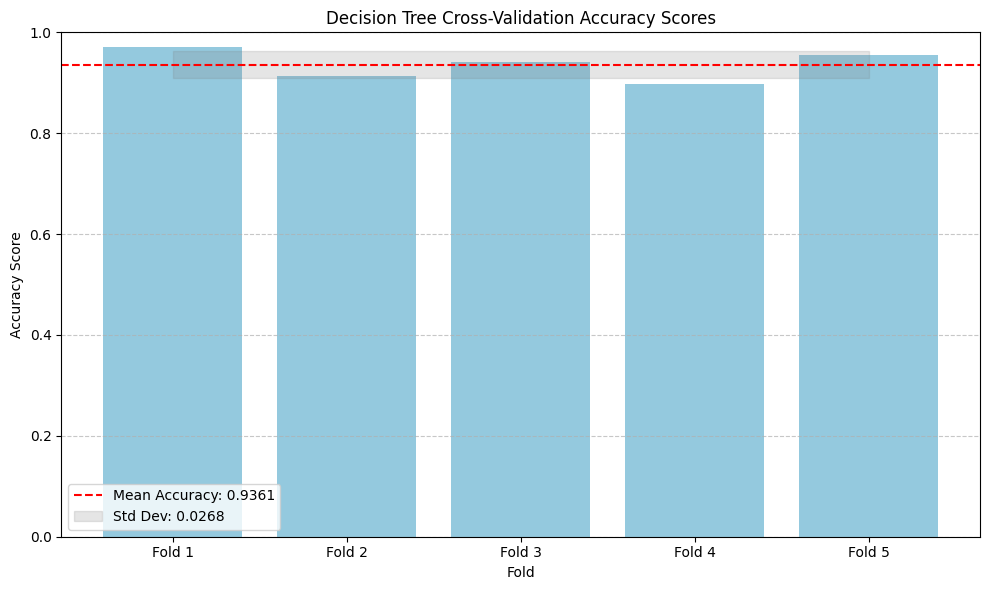

In [ ]:
# visualizacion de los folds del DTC

import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(len(scores_dt)), y=scores_dt, color='skyblue')
plt.axhline(scores_dt.mean(), color='r', linestyle='--', label=f'Mean Accuracy: {scores_dt.mean():.4f}')
plt.fill_between(x=np.arange(len(scores_dt)),
                 y1=scores_dt.mean() - scores_dt.std(),
                 y2=scores_dt.mean() + scores_dt.std(),
                 color='gray', alpha=0.2, label=f'Std Dev: {scores_dt.std():.4f}')
plt.xlabel("Fold")
plt.ylabel("Accuracy Score")
plt.title("Decision Tree Cross-Validation Accuracy Scores")
plt.xticks(np.arange(len(scores_dt)), [f'Fold {i+1}' for i in range(len(scores_dt))])
plt.ylim(0.0, 1.0) # Accuracy is between 0 and 1
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

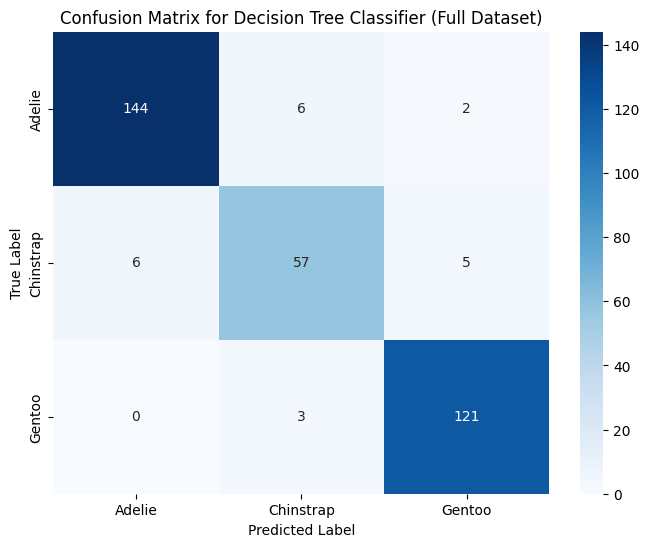

In [114]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
import seaborn as sns
import matplotlib.pyplot as plt

predictions_dtc = cross_val_predict(
    dt_pipeline,
    X,
    y,
    cv=kf
)

cm = confusion_matrix(y, predictions_dtc)

class_names_cm = sorted(y.unique().astype(str))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_cm, yticklabels=class_names_cm)
plt.title("Confusion Matrix for Decision Tree Classifier (Full Dataset)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

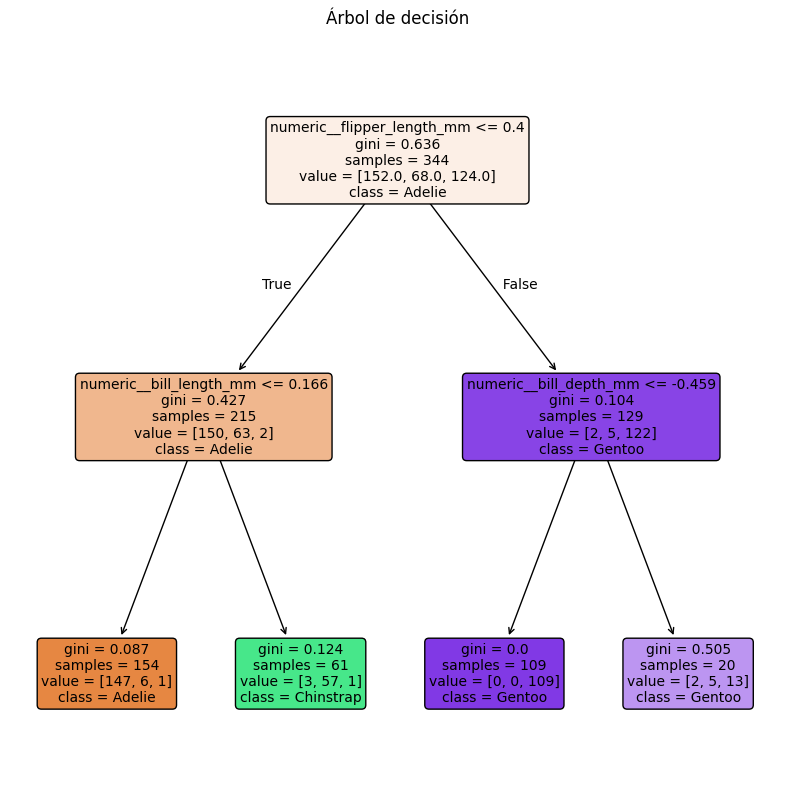

In [115]:
# entreno el DTC

dt_pipeline.fit(X,y)

# visualizacion del arbol
trained_dt_classifier = dt_pipeline.named_steps["classifier"]
feature_names = (
    dt_pipeline
    .named_steps["preprocessing"]
    .named_steps["columntransformer"]
    .get_feature_names_out()
)


class_names = sorted(y.unique().astype(str))
plt.figure(figsize=(10, 10))

plot_tree(
    trained_dt_classifier,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión")
plt.show()


# KNN - K Nearest Neighbors

In [116]:
from sklearn.neighbors import KNeighborsClassifier

neigh = KNeighborsClassifier(n_neighbors=2)

knn_pipeline = Pipeline(
    [("preprocessing", preprocessing_pipeline),
     ("classifier", neigh)]
)

scores_knn = cross_val_score(knn_pipeline,
                            X,
                            y,
                            cv=kf,
                            scoring="accuracy")

print(f"Puntajes KNN Cross-Validation: {scores_knn}")
print(f"Precision media: {scores_knn.mean():.4f}")
print(f"Desviacion standard: {scores_knn.std():.4f}")


Puntajes KNN Cross-Validation: [1.         0.98550725 0.98550725 0.98550725 0.98529412]
Precision media: 0.9884
Desviacion standard: 0.0058


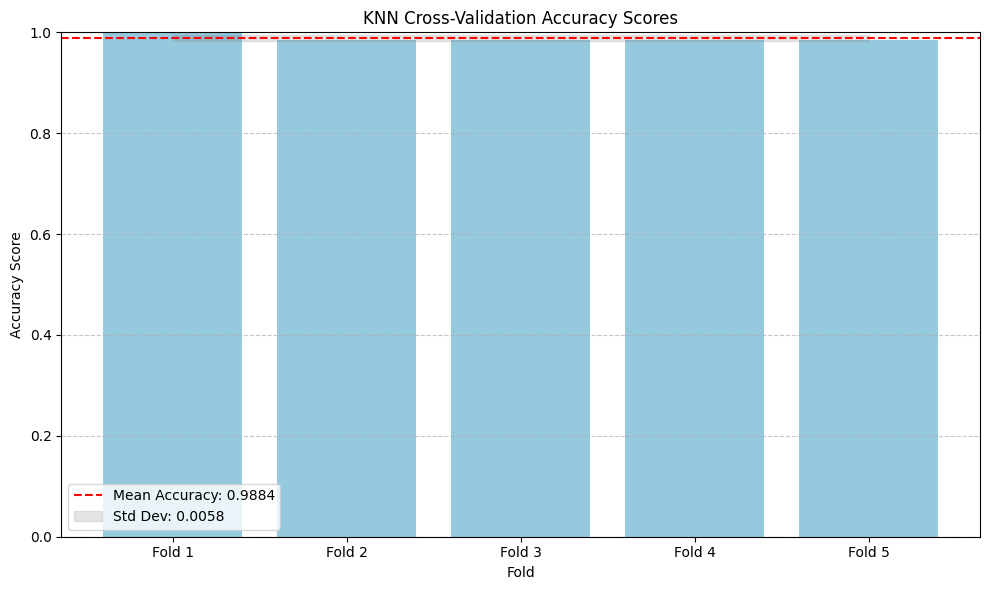

In [117]:
# visualizacion de los folds del KNN classifier

import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=np.arange(len(scores_knn)), y=scores_knn, color='skyblue')
plt.axhline(scores_knn.mean(), color='r', linestyle='--', label=f'Mean Accuracy: {scores_knn.mean():.4f}')
plt.fill_between(x=np.arange(len(scores_knn)),
                 y1=scores_knn.mean() - scores_knn.std(),
                 y2=scores_knn.mean() + scores_knn.std(),
                 color='gray', alpha=0.2, label=f'Std Dev: {scores_knn.std():.4f}')
plt.xlabel("Fold")
plt.ylabel("Accuracy Score")
plt.title("KNN Cross-Validation Accuracy Scores")
plt.xticks(np.arange(len(scores_knn)), [f'Fold {i+1}' for i in range(len(scores_knn))])
plt.ylim(0.0, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

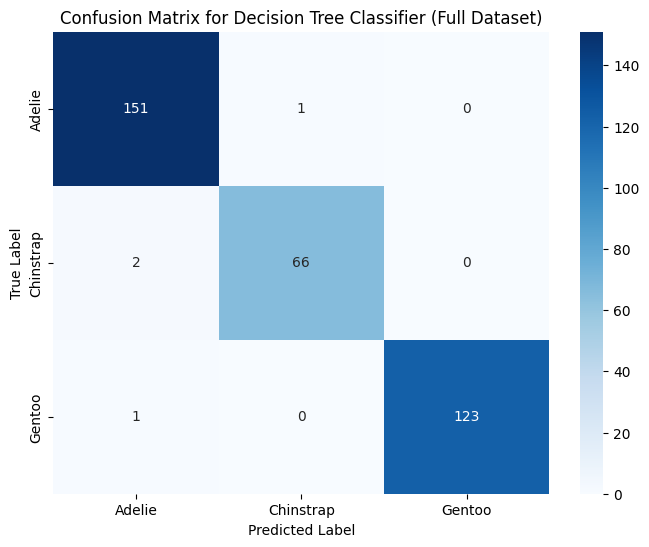

In [118]:
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_predict
import seaborn as sns
import matplotlib.pyplot as plt

predictions_knn = cross_val_predict(
    knn_pipeline,
    X,
    y,
    cv=kf
)

cm = confusion_matrix(y, predictions_knn)

class_names_cm = sorted(y.unique().astype(str))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names_cm, yticklabels=class_names_cm)
plt.title("Confusion Matrix for K Nearest Neighbors Classifier (Full Dataset)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

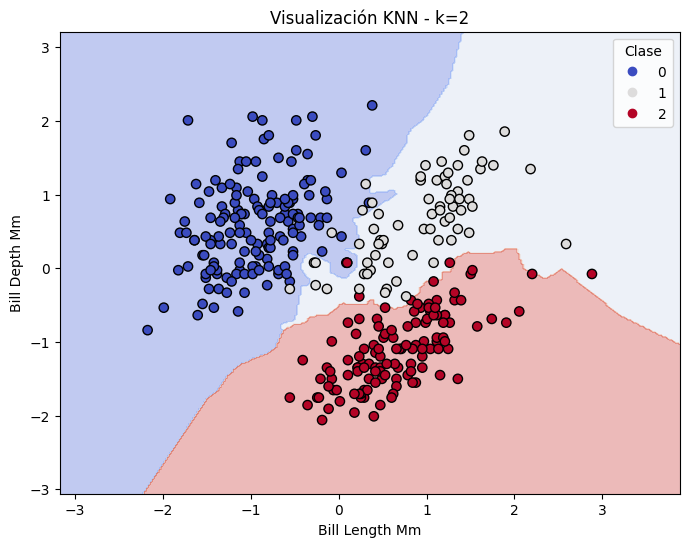

In [138]:
# --- visualizacion del KNN ---
# comparacion basada en features : bill_length_mm y bill_depth_mm

import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import KNeighborsClassifier

# Entrenar pipeline completo
knn_pipeline.fit(X, y)

# Obtener preprocesador y clasificador entrenado
preprocessor = knn_pipeline.named_steps["preprocessing"]
knn_classifier = knn_pipeline.named_steps["classifier"]

# Transformar X
X_transformed = preprocessor.transform(X)

# Variables a visualizar
features_to_plot = [
    "numeric__bill_length_mm",
    "numeric__bill_depth_mm"
]

# Seleccionar las dos columnas y convertir directamente a NumPy
X_plot = X_transformed[features_to_plot].to_numpy()

# Convertir clases a números para graficar
classes = np.unique(y)
class_to_int = {label: i for i, label in enumerate(classes)}
y_int = np.array([class_to_int[label] for label in y])

# Entrenar un KNN solo con las dos variables para visualizar en 2D
knn_2d = KNeighborsClassifier(
    n_neighbors=knn_classifier.n_neighbors
)

knn_2d.fit(X_plot, y_int)

# Graficar
fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    knn_2d,
    X_plot,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.35,
    grid_resolution=300,
    ax=ax
)

handles, labels = scatter.legend_elements()

scatter = ax.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=y_int,
    cmap=plt.cm.coolwarm,
    edgecolor="k",
    s=45
)

ax.set_xlabel("Bill Length Mm")
ax.set_ylabel("Bill Depth Mm")
ax.set_title(f"Visualización KNN - k={knn_classifier.n_neighbors}")

ax.legend(
    handles=handles,
    labels=labels,
    title="Clase"
)

plt.show()

# e) Evaluar los dos clasificadores y compararlos, indicando cual de los dos recomendaría.

